When running DoWhy with ordinal variables (such as Likert scales or ordered categories), treat them either as numeric integers if distances are roughly equal, or encode them as dummy/one-hot variables if the spacing is non-linear. Pass the processed dataframe into CausalModel and select a robust estimator like propensity-based weighting or generalized linear models.Handling Ordinal Data PreparationConvert ordered values (e.g., 0, 1, 2, 3) to integers if you assume linear steps between categories.Use one-hot encoding via pandas for unordered or non-uniform multi-class categorical treatments/outcomes.Keep the causal graph definition clean in Step 1, ensuring ordinal confounders connect properly to treatments and outcomes.Choosing an EstimatorLinear/Regression Estimators: Use econml or standard backdoor linear methods if ordinal variables serve as continuous approximations.Propensity Score Methods: Use stratification or inverse probability weighting (backdoor.propensity_score_weighting) when the ordinal variable acts as a multi-class treatment.Generalized Linear Models (GLM): Apply logistic or ordinal regression wrappers through EconML/DoWhy integration for binary or categorical outcomes.Example Code Patternpythonimport dowhy
from dowhy import CausalModel
# Assume df has ordinal column 'education_level' (0, 1, 2)
model = CausalModel(
    data=df,
    treatment='treatment_var',
    outcome='outcome_var',
    common_causes=['education_level', 'age']
)
identified_estimand = model.identify_effect()
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting"
)

In [1]:
import os
os.environ["JOBLIB_MULTIPROCESSING"] = "0"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from dowhy.gcm.falsify import falsify_graph
from dowhy.gcm.util.general import set_random_seed
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
from networkx.drawing.nx_pydot import read_dot

import pingouin as pg
import warnings
warnings.filterwarnings('ignore')

/Users/psr/Documents/MSI608/causal/WOS1/Target-PC-LINGAM_paper/PC_SGP/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
set_random_seed(1332)

GRAPH_FILE = "PC_output_graph.dot"
DATA_FILE = "dataset_270411_final_ingles_sin_GP.csv"

print("Cargando grafo...")

#g = nx.read_gml(GRAPH_FILE)
g = read_dot(GRAPH_FILE)
g = nx.DiGraph(g)

print(f"Nodos: {g.number_of_nodes()}")
print(f"Aristas: {g.number_of_edges()}")

print("Verificando si el grafo es DAG...")

g_dag = g.copy()

while not nx.is_directed_acyclic_graph(g_dag):
    cycle = list(nx.simple_cycles(g_dag))[0]
    u, v = cycle[-1], cycle[0]

    print(f"Eliminando arista {u} -> {v}")

    g_dag.remove_edge(u, v)

print("DAG válido obtenido")


Cargando grafo...
Nodos: 14
Aristas: 54
Verificando si el grafo es DAG...
DAG válido obtenido


In [3]:
# Create a mapping dictionary where quotes are stripped from the labels
mapping = {node: data["label"].strip('"') for node, data in g_dag.nodes(data=True) if "label" in data}

# Transform the graph structure permanently
nx.relabel_nodes(g_dag, mapping, copy=False)

In [4]:
nodos=sorted(list(g_dag.nodes()))

In [5]:
A=nx.to_numpy_array(g_dag,nodelist=nodos).round(1)

In [6]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [7]:
nodos

['AVERAGE_MATH_LANG',
 'FATHER_EDUCATION',
 'GENDER',
 'GRADUATION_YEAR',
 'HOW_MANY_STUDY',
 'HOW_MANY_WORK',
 'INCOME_PERCENTILE',
 'MOTHER_EDUCATION',
 'PREVIOUS_ADMISSION',
 'RURAL',
 'SCHOOL_DEPENDENCY',
 'SCHOOL_TYPE',
 'SCORE_NEM',
 'WORK']

<Axes: >

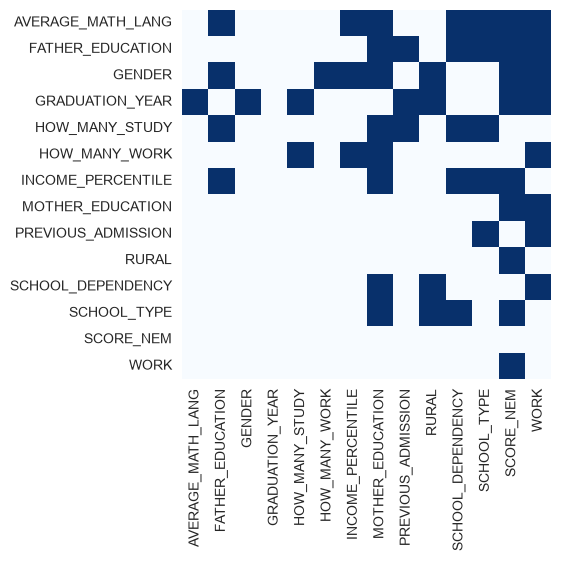

In [8]:
sns.set_style("white")
sns.heatmap(np.where(A!=0,1,0),square=True,cmap="Blues",
            xticklabels=nodos,yticklabels=nodos,cbar=False)

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from dowhy.gcm.falsify import FalsifyConst, falsify_graph, plot_local_insights, run_validations, apply_suggestions
from dowhy.gcm.independence_test.generalised_cov_measure import generalised_cov_based
from dowhy.gcm.util import plot
from dowhy.gcm.util.general import set_random_seed
from dowhy.gcm.ml import SklearnRegressionModel

In [10]:
data = pd.read_csv(f"dataset_270411_final_ingles_sin_GPSR.csv", sep=';')

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 270411 entries, 0 to 270410
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   GRADUATION_YEAR     270411 non-null  int64  
 1   SCORE_NEM           270411 non-null  int64  
 2   AVERAGE_MATH_LANG   270411 non-null  float64
 3   GENDER              270411 non-null  int64  
 4   HOW_MANY_WORK       270411 non-null  int64  
 5   HOW_MANY_STUDY      270411 non-null  int64  
 6   INCOME_PERCENTILE   270411 non-null  int64  
 7   MOTHER_EDUCATION    270411 non-null  int64  
 8   FATHER_EDUCATION    270411 non-null  int64  
 9   PREVIOUS_ADMISSION  270411 non-null  int64  
 10  SCHOOL_TYPE         270411 non-null  int64  
 11  SCHOOL_DEPENDENCY   270411 non-null  int64  
 12  WORK                270411 non-null  int64  
 13  RURAL               270411 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 28.9 MB


In [12]:
if not nx.is_directed_acyclic_graph(g_dag):
    print("Error: el gráfico proporcionado no es un DAG")
else:
    print("DAG VALIDO")

DAG VALIDO


In [13]:
nx.write_gml(g_dag, "PC_output_graph.gml")

In [14]:
from dowhy import gcm

In [15]:
np.random.seed(0)

In [16]:
causal_model = gcm.InvertibleStructuralCausalModel(g_dag)
gcm.auto.assign_causal_mechanisms(causal_model, data, quality=gcm.auto.AssignmentQuality.BETTER)
gcm.fit(causal_model, data)

Fitting causal mechanism of node SCORE_NEM: 100%|██████████| 14/14 [2:01:25<00:00, 520.37s/it]           


In [17]:
joblib.dump(causal_model, 'causal_model.joblib')

['causal_model.joblib']

In [18]:
causal_model = joblib.load('causal_model.joblib')

In [19]:
strength = gcm.arrow_strength(causal_model, 'SCORE_NEM')
strength

{('AVERAGE_MATH_LANG', 'SCORE_NEM'): np.float64(4074.83999495),
 ('FATHER_EDUCATION', 'SCORE_NEM'): np.float64(41.09581089075622),
 ('GENDER', 'SCORE_NEM'): np.float64(458.9671295459185),
 ('GRADUATION_YEAR', 'SCORE_NEM'): np.float64(867.8479234329269),
 ('INCOME_PERCENTILE', 'SCORE_NEM'): np.float64(19.23725019206347),
 ('MOTHER_EDUCATION', 'SCORE_NEM'): np.float64(10.327257497282591),
 ('RURAL', 'SCORE_NEM'): np.float64(8.335864977672031),
 ('SCHOOL_TYPE', 'SCORE_NEM'): np.float64(26.92130925792682),
 ('WORK', 'SCORE_NEM'): np.float64(18.156793456716446)}

In [20]:
joblib.dump(strength, 'strength.joblib')

['strength.joblib']

In [21]:
strength = joblib.load('strength.joblib')

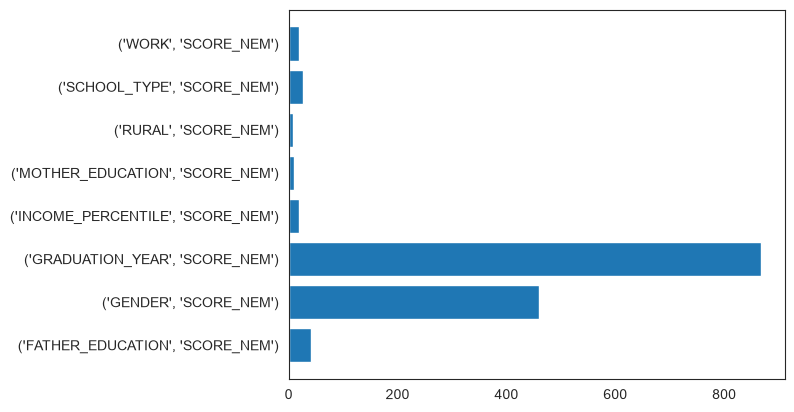

In [22]:
x=[]
y=[]
for key in strength:
    if key not in [('AVERAGE_MATH_LANG', 'SCORE_NEM')]:
        x.append(key)
        y.append(strength[key])
plt.barh(list(map(str,x)),y);

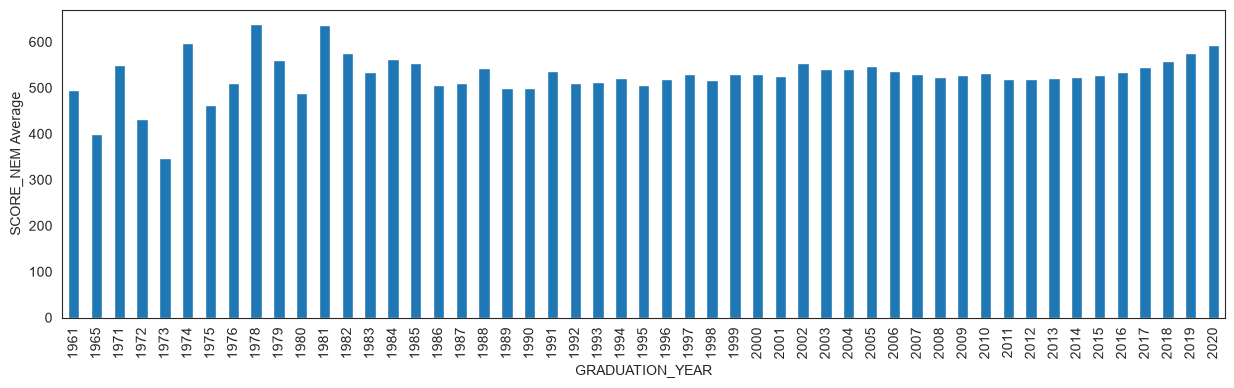

In [23]:
fig, axes = plt.subplots(1,1)
fig.set_size_inches(15, 4)
data.groupby("GRADUATION_YEAR")["SCORE_NEM"].mean().plot.bar(ax=axes)
axes.set_ylabel("SCORE_NEM Average");

In [24]:
contributions = gcm.intrinsic_causal_influence(causal_model, 'SCORE_NEM')
contributions

Evaluating set functions...: 100%|██████████| 295/295 [05:20<00:00,  1.08s/it]


{'GRADUATION_YEAR': np.float64(737.4003542472669),
 'AVERAGE_MATH_LANG': np.float64(4073.9561676137832),
 'GENDER': np.float64(345.3620429835981),
 'HOW_MANY_WORK': np.float64(0.17575229131644884),
 'HOW_MANY_STUDY': np.float64(-0.07868240504353968),
 'INCOME_PERCENTILE': np.float64(1.796781520279948),
 'FATHER_EDUCATION': np.float64(9.80555872779896),
 'PREVIOUS_ADMISSION': np.float64(-1.1149525747100597e-13),
 'SCHOOL_TYPE': np.float64(1.6694218795978535),
 'SCHOOL_DEPENDENCY': np.float64(-1.3986878629387869),
 'MOTHER_EDUCATION': np.float64(-2.234642194394736),
 'RURAL': np.float64(5.192511696220615),
 'WORK': np.float64(-9.513348549586924),
 'SCORE_NEM': np.float64(6424.733023483517)}

scikit-learn == 1.5.2 for restoring
scikit-learn == 1.9.1 for econml

In [25]:
joblib.dump(contributions, 'contributions.joblib')

['contributions.joblib']

In [26]:
contributions = joblib.load('contributions.joblib')

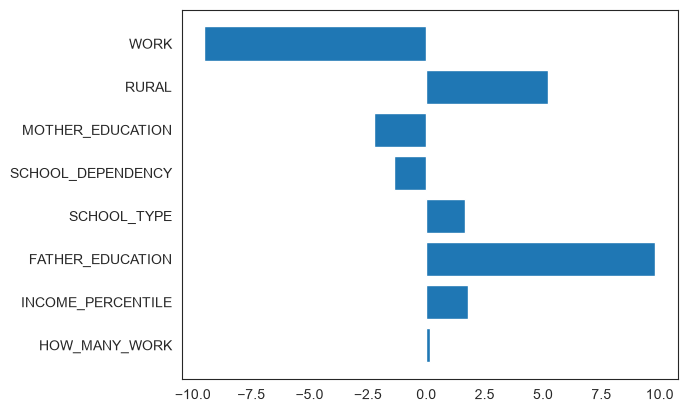

In [27]:
x=[]
y=[]
for key in contributions:
    if key not in ['AVERAGE_MATH_LANG',
                   'SCORE_NEM','GRADUATION_YEAR',
                   'GENDER','PREVIOUS_ADMISSION','HOW_MANY_STUDY']:
        x.append(key)
        y.append(contributions[key])
plt.barh(list(map(str,x)),y);

In [28]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='GRADUATION_YEAR',detailed=True)
res

,Source,ddof1,H,p_unc
Kruskal,GRADUATION_YEAR,50,8088.62875,0.0


In [29]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='SCHOOL_TYPE',detailed=True)
res

,Source,ddof1,H,p_unc
Kruskal,SCHOOL_TYPE,1,7318.839988,0.0


In [30]:
data.groupby("SCHOOL_TYPE")["SCORE_NEM"].mean()

SCHOOL_TYPE
0    593.377734
1    550.972063
Name: SCORE_NEM, dtype: float64

In [31]:
data["GENDER"]=data["GENDER"].apply(lambda x : x-1)

In [32]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='GENDER',detailed=True)
res

,Source,ddof1,H,p_unc
Kruskal,GENDER,1,5330.851597,0.0


In [33]:
data.groupby("GENDER")["SCORE_NEM"].mean()

GENDER
0    565.697423
1    596.405030
Name: SCORE_NEM, dtype: float64

In [34]:
pg.compute_effsize( data.query("GENDER==1")["SCORE_NEM"],
                    data.query("GENDER==0")["SCORE_NEM"],
                    eftype='cohen')

In [35]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='WORK',detailed=True)
res

,Source,ddof1,H,p_unc
Kruskal,WORK,1,3954.746525,0.0


posthoc = pg.pairwise_tests(
    data=data, 
    between='WORK', 
    dv='SCORE_NEM',
    parametric=False, 
    padjust='none',
    effsize="cohen"
)
posthoc

In [36]:
data.groupby("WORK")["SCORE_NEM"].mean()

WORK
0    586.090954
1    532.969754
Name: SCORE_NEM, dtype: float64

In [37]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='HOW_MANY_WORK',detailed=True)
res

,Source,ddof1,H,p_unc
Kruskal,HOW_MANY_WORK,7,661.802275,1.181449e-138


In [38]:
norm_test = pg.normality(data=data, dv='SCORE_NEM', group='MOTHER_EDUCATION')
hom_test = pg.homoscedasticity(data=data, dv='SCORE_NEM', group='MOTHER_EDUCATION')
#For repeated measures ANOVA
#sph_test = pg.sphericity(data=data, dv='SCORE_NEM', within='time', subject='MOTHER_EDUCATION')
print(norm_test)
print(hom_test)

                         W          pval  normal
MOTHER_EDUCATION                                
6                 0.993586  1.556121e-20   False
5                 0.994225  1.640009e-35   False
4                 0.993275  1.344594e-20   False
7                 0.993245  2.370894e-48   False
1                 0.990104  2.758880e-07   False
9                 0.992954  9.135811e-36   False
11                0.983099  2.757062e-53   False
2                 0.986423  4.268376e-06   False
10                0.991176  4.877353e-40   False
8                 0.991709  9.111684e-29   False
12                0.964352  1.899222e-35   False
3                 0.995282  1.808085e-01    True
               W          pval  equal_var
levene  21.74497  5.348215e-45      False


In [39]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='FATHER_EDUCATION',detailed=True)
res

,Source,ddof1,H,p_unc
Kruskal,FATHER_EDUCATION,11,14846.521432,0.0


In [40]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='MOTHER_EDUCATION',detailed=True)
res

,Source,ddof1,H,p_unc
Kruskal,MOTHER_EDUCATION,11,13211.874683,0.0


In [41]:
norm_test = pg.normality(data=data, dv='SCORE_NEM', group='INCOME_PERCENTILE')
hom_test = pg.homoscedasticity(data=data, dv='SCORE_NEM', group='INCOME_PERCENTILE')
#For repeated measures ANOVA
#sph_test = pg.sphericity(data=data, dv='SCORE_NEM', within='time', subject='MOTHER_EDUCATION')
print(norm_test)
print(hom_test)

                          W          pval  normal
INCOME_PERCENTILE                                
3                  0.992502  6.779734e-39   False
8                  0.991255  1.352613e-33   False
1                  0.993478  2.470424e-42   False
2                  0.993404  4.359108e-36   False
4                  0.993148  1.281545e-32   False
9                  0.988590  3.194558e-37   False
7                  0.991462  4.906386e-31   False
10                 0.973455  2.196519e-49   False
6                  0.992375  5.913557e-29   False
5                  0.992330  1.087033e-30   False
                W          pval  equal_var
levene  27.676713  1.638722e-48      False


In [42]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='INCOME_PERCENTILE',detailed=True)
res

,Source,ddof1,H,p_unc
Kruskal,INCOME_PERCENTILE,9,8557.65179,0.0


In [43]:
data.groupby("INCOME_PERCENTILE")["SCORE_NEM"].agg(["mean","std"]).round(2)

,mean,std
INCOME_PERCENTILE,,
1,562.93,104.73
2,571.71,105.32
3,577.60,105.63
4,580.40,104.98
5,584.96,105.41
6,588.89,105.11
7,587.14,106.10
8,578.78,108.36
9,602.95,109.88


In [44]:
h_stat = res.loc['Kruskal', 'H']
n = data['SCORE_NEM'].count()  # Total sample size
k = data['MOTHER_EDUCATION'].nunique() 

Common guidelines for interpreting these effect sizes 
$(\eta ^{2} are:)$

$(Small: 0.01 \leq \text{effect} < 0.06
Moderate: 0.06 \leq \text{effect} < 0.14
Large: \text{effect} \geq 0.14)$

In [45]:
epsilon_sq = h_stat / ((n**2 - 1) / (n + 1))
print(f"Epsilon-squared: {epsilon_sq:.4f}")

Epsilon-squared: 0.0316


In [46]:
eta_sq = (h_stat - k + 1) / (n - k)
print(f"Eta-squared: {eta_sq:.4f}")

Eta-squared: 0.0316


In [47]:
norm_test = pg.normality(data=data, dv='SCORE_NEM', group='RURAL')
hom_test = pg.homoscedasticity(data=data, dv='SCORE_NEM', group='RURAL')
print(norm_test,hom_test)

              W          pval  normal
RURAL                                
0      0.991688  1.674127e-61   False
1      0.991590  4.858951e-56   False                W      pval  equal_var
levene  4.584006  0.032273      False


In [48]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='RURAL',detailed=True)
res

,Source,ddof1,H,p_unc
Kruskal,RURAL,1,101.334215,7.770194e-24


In [49]:
data.groupby("RURAL")["SCORE_NEM"].mean()

RURAL
0    584.322063
1    579.885463
Name: SCORE_NEM, dtype: float64

In [50]:
data.groupby("RURAL")["SCORE_NEM"].count()

RURAL
0    161686
1    108725
Name: SCORE_NEM, dtype: int64

In [51]:
h_stat = res.loc['Kruskal', 'H']
n = data['SCORE_NEM'].count()  # Total sample size
k = data['WORK'].nunique() 

In [52]:
epsilon_sq = h_stat / ((n**2 - 1) / (n + 1))
print(f"Epsilon-squared: {epsilon_sq:.4f}")

Epsilon-squared: 0.0004


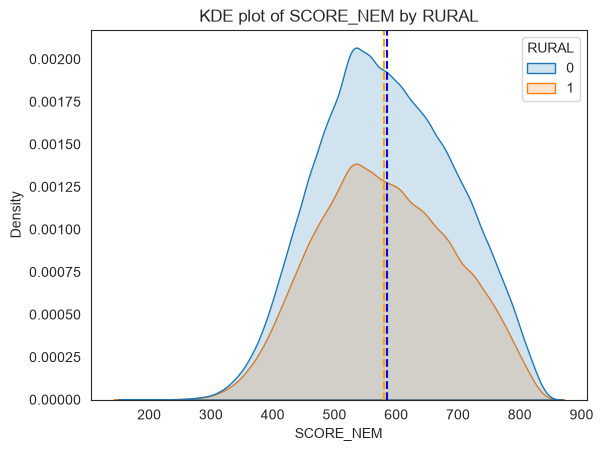

In [53]:
group_means = data.groupby('RURAL')['SCORE_NEM'].mean()
ax = sns.kdeplot(data=data, x='SCORE_NEM', 
                 hue='RURAL', common_norm=True, fill=True, alpha=0.2)
plt.axvline(group_means[0], color='blue', linestyle='--')
plt.axvline(group_means[1], color='orange', linestyle='--')
plt.title('KDE plot of SCORE_NEM by RURAL')
plt.show()


In [54]:
norm_test = pg.normality(data=data, dv='SCORE_NEM', group='WORK')
hom_test = pg.homoscedasticity(data=data, dv='SCORE_NEM', group='WORK')
print(norm_test,hom_test)

             W          pval  normal
WORK                                
1     0.987852  3.225661e-36   False
0     0.991722  1.370963e-67   False                 W          pval  equal_var
levene  65.033511  7.393242e-16      False


In [55]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='WORK',detailed=True)
res

,Source,ddof1,H,p_unc
Kruskal,WORK,1,3954.746525,0.0


In [56]:
h_stat = res.loc['Kruskal', 'H']
n = data['SCORE_NEM'].count()  # Total sample size
k = data['WORK'].nunique() 

In [57]:
epsilon_sq = h_stat / ((n**2 - 1) / (n + 1))
print(f"Epsilon-squared: {epsilon_sq:.4f}")

Epsilon-squared: 0.0146


In [58]:
data.groupby("WORK")["SCORE_NEM"].agg(["mean","std"]).round(2)

,mean,std
WORK,,
0,586.09,107.30
1,532.97,104.91


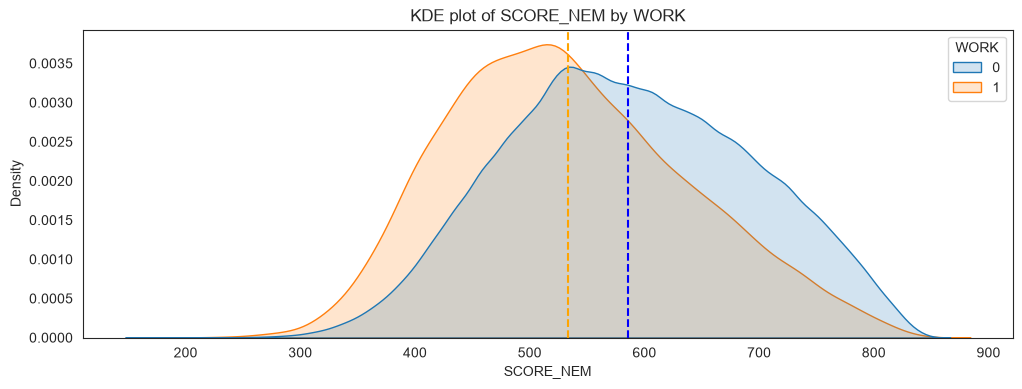

In [59]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(12, 4)
group_means = data.groupby('WORK')['SCORE_NEM'].mean()
sns.kdeplot(data=data, x='SCORE_NEM', 
            hue='WORK', common_norm=False, fill=True, alpha=0.2, ax=ax)
plt.axvline(group_means[0], color='blue', linestyle='--')
plt.axvline(group_means[1], color='orange', linestyle='--')
plt.title('KDE plot of SCORE_NEM by WORK')
plt.show()

In [60]:
norm_test = pg.normality(data=data, dv='SCORE_NEM', group='SCHOOL_TYPE')
hom_test = pg.homoscedasticity(data=data, dv='SCORE_NEM', group='SCHOOL_TYPE')
print(norm_test,hom_test)

                    W          pval  normal
SCHOOL_TYPE                                
0            0.990586  3.369861e-67   False
1            0.993855  5.232888e-44   False                   W           pval  equal_var
levene  1098.147624  2.542500e-240      False


In [61]:
res=pg.kruskal(data=data, dv='SCORE_NEM', between='SCHOOL_TYPE',detailed=True)
res

,Source,ddof1,H,p_unc
Kruskal,SCHOOL_TYPE,1,7318.839988,0.0


In [62]:
h_stat = res.loc['Kruskal', 'H']
n = data['SCORE_NEM'].count()  # Total sample size
k = data['SCHOOL_TYPE'].nunique() 

In [63]:
epsilon_sq = h_stat / ((n**2 - 1) / (n + 1))
print(f"Epsilon-squared: {epsilon_sq:.4f}")

Epsilon-squared: 0.0271


SIMULATED
0    593.377734
1    592.361836
Name: SCORE_NEM, dtype: float64             Source  ddof1         H     p_unc
Kruskal  SIMULATED      1  3.139669  0.076409


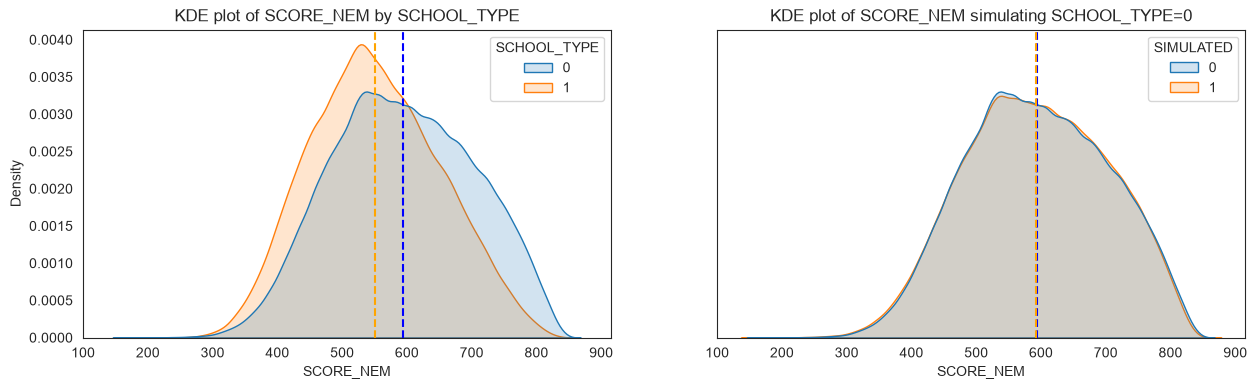

In [64]:
observed=data.query("SCHOOL_TYPE==0")
simulacion=gcm.counterfactual_samples(
    causal_model,
    {'SCHOOL_TYPE': lambda x: 1},
    observed_data=observed)
observed["SIMULATED"]=0
simulacion["SIMULATED"]=1
consolidado=pd.concat([observed,simulacion])
fig, axes = plt.subplots(1,2,sharex=True,sharey=True)
fig.set_size_inches(15, 4)

group_means = data.groupby('SCHOOL_TYPE')['SCORE_NEM'].mean()
sns.kdeplot(data=data, x='SCORE_NEM', hue='SCHOOL_TYPE', common_norm=False, fill=True, alpha=0.2,ax=axes[0])
axes[0].axvline(group_means[0], color='blue', linestyle='--')
axes[0].axvline(group_means[1], color='orange', linestyle='--')
axes[0].set_title('KDE plot of SCORE_NEM by SCHOOL_TYPE');

group_means = consolidado.groupby('SIMULATED')['SCORE_NEM'].mean()
sns.kdeplot(data=consolidado, x='SCORE_NEM', hue='SIMULATED', common_norm=False, fill=True, alpha=0.2,ax=axes[1])
axes[1].axvline(group_means[0], color='blue', linestyle='--')
axes[1].axvline(group_means[1], color='orange', linestyle='--')
axes[1].set_title('KDE plot of SCORE_NEM simulating SCHOOL_TYPE=0');


res=pg.kruskal(data=consolidado, dv='SCORE_NEM', between='SIMULATED',detailed=True)
print(group_means,res)


OLS model fitted successfully.
                            OLS Regression Results                            
Dep. Variable:              SCORE_NEM   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     4109.
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:44:45   Log-Likelihood:            -1.6342e+06
No. Observations:              270411   AIC:                         3.268e+06
Df Residuals:                  270402   BIC:                         3.268e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const 

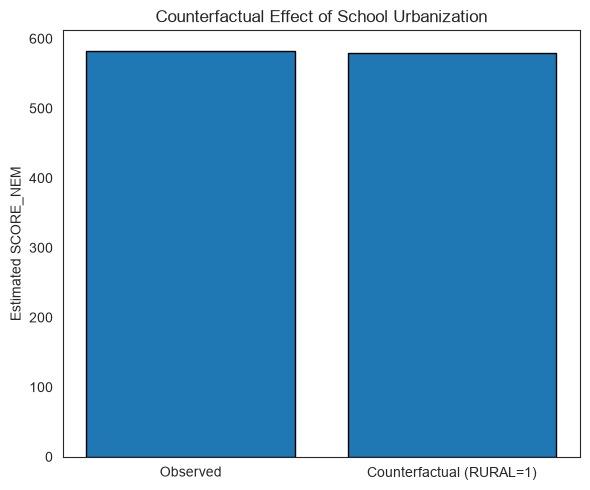

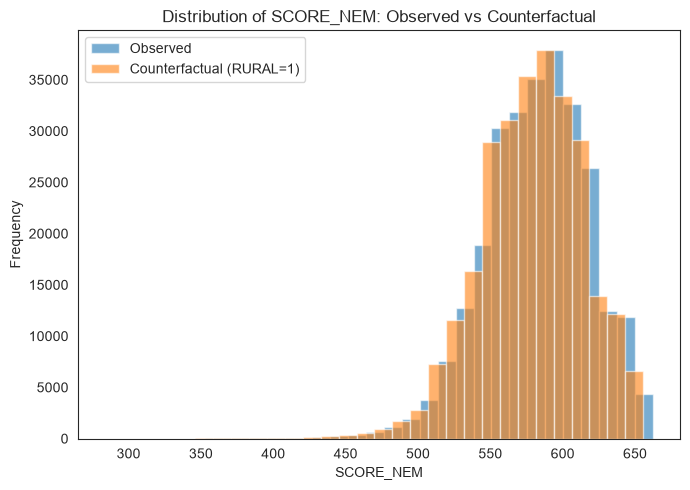

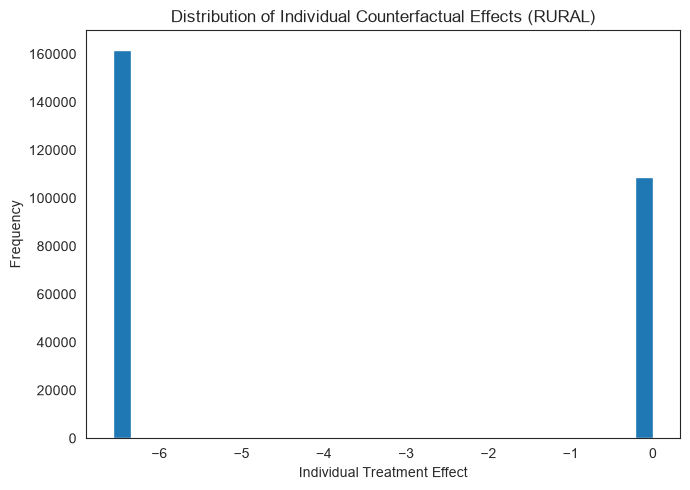


All figures generated successfully.


In [65]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

# =====================================
# 1. Load dataset
# =====================================
df = pd.read_csv("dataset_270411_final_ingles.csv", sep=";")

# =====================================
# 2. Define variables
# =====================================
Y_VAR = "SCORE_NEM"

X_VARS = [
    "SCHOOL_TYPE",
    "GRADUATION_YEAR",
    "GENDER",
    "MOTHER_EDUCATION",
    "INCOME_PERCENTILE",
    "HOW_MANY_WORK",
    "WORK",
    "RURAL",
]

df_model = df[X_VARS]
df_model[Y_VAR]=df[Y_VAR]

X = sm.add_constant(df_model[X_VARS])
y = df_model[Y_VAR]

# =====================================
# 3. Fit OLS model
# =====================================
model = sm.OLS(y, X).fit()

print("\nOLS model fitted successfully.")
print(model.summary())

# =====================================
# 4. Observed predictions
# =====================================
df_model["SCORE_NEM_observed"] = model.predict(X)

# =====================================
# 5. Counterfactual intervention:
#    RURAL = 0  ---> RURAL = 1
# =====================================
X_cf = X.copy()

# Apply intervention only to rural students
X_cf.loc[X_cf["RURAL"] == 0, "RURAL"] = 1

df_model["SCORE_NEM_counterfactual"] = model.predict(X_cf)

# =====================================
# 6. Individual treatment effect
# =====================================
df_model["Individual_Effect"] = (
    df_model["SCORE_NEM_counterfactual"] - df_model["SCORE_NEM_observed"]
)

# Save results
df_model[
    ["RURAL", "SCORE_NEM_observed", "SCORE_NEM_counterfactual", "Individual_Effect"]
].to_csv(
    "counterfactual_RURAL_0_to_1.csv",
    sep=";",
    index=False
)

print("\nCounterfactual results saved to 'counterfactual_RURAL_0_to_1.csv'.")

# =====================================
# 7. Aggregate effects
# =====================================
avg_observed = df_model["SCORE_NEM_observed"].mean()
avg_counterfactual = df_model["SCORE_NEM_counterfactual"].mean()
avg_effect = df_model["Individual_Effect"].mean()

print("\nAverage Effects:")
print(f"Observed mean SCORE_NEM: {avg_observed:.3f}")
print(f"Counterfactual mean SCORE_NEM (RURAL=1): {avg_counterfactual:.3f}")
print(f"Average Treatment Effect (ATE): {avg_effect:.3f}")

# =====================================
# 8. Comparative figures (paper-ready)
# =====================================

# --- Figure 1: Mean comparison ---
plt.figure(figsize=(6, 5))
plt.bar(
    ["Observed", "Counterfactual (RURAL=1)"],
    [avg_observed, avg_counterfactual],
    edgecolor="black"
)
plt.ylabel("Estimated SCORE_NEM")
plt.title("Counterfactual Effect of School Urbanization")
plt.tight_layout()
plt.savefig("Figure_RURAL_Observed_vs_Counterfactual.png", dpi=300)
plt.show()

# --- Figure 2: Distribution comparison ---
plt.figure(figsize=(7, 5))
plt.hist(
    df_model["SCORE_NEM_observed"],
    bins=30,
    alpha=0.6,
    label="Observed"
)
plt.hist(
    df_model["SCORE_NEM_counterfactual"],
    bins=30,
    alpha=0.6,
    label="Counterfactual (RURAL=1)"
)
plt.xlabel("SCORE_NEM")
plt.ylabel("Frequency")
plt.title("Distribution of SCORE_NEM: Observed vs Counterfactual")
plt.legend()
plt.tight_layout()
plt.savefig("Figure_RURAL_Distribution_Comparison.png", dpi=300)
plt.show()

# --- Figure 3: Individual effects ---
plt.figure(figsize=(7, 5))
plt.hist(df_model["Individual_Effect"], bins=30)
plt.xlabel("Individual Treatment Effect")
plt.ylabel("Frequency")
plt.title("Distribution of Individual Counterfactual Effects (RURAL)")
plt.tight_layout()
plt.savefig("Figure_RURAL_Individual_Effects.png", dpi=300)
plt.show()

print("\nAll figures generated successfully.")

G-computation uses a fitted model to predict scenario for treatment==1 and treatment==0 and makes the difference of stimates of the outcome to calculate and ATE (Average Treatment Effect)


OLS model fitted successfully.
                            OLS Regression Results                            
Dep. Variable:              SCORE_NEM   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     4109.
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:44:47   Log-Likelihood:            -1.6342e+06
No. Observations:              270411   AIC:                         3.268e+06
Df Residuals:                  270402   BIC:                         3.268e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const 

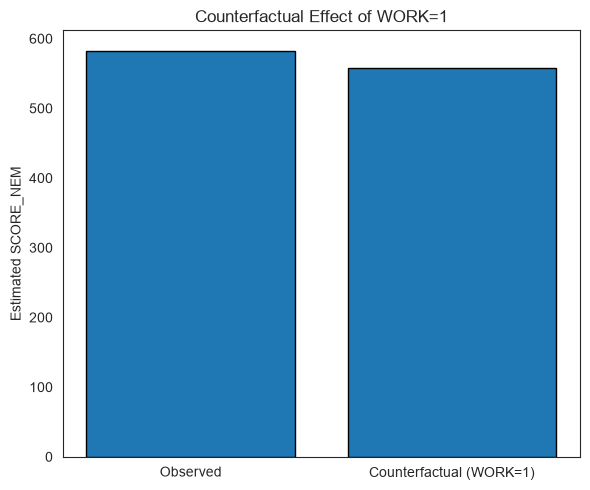

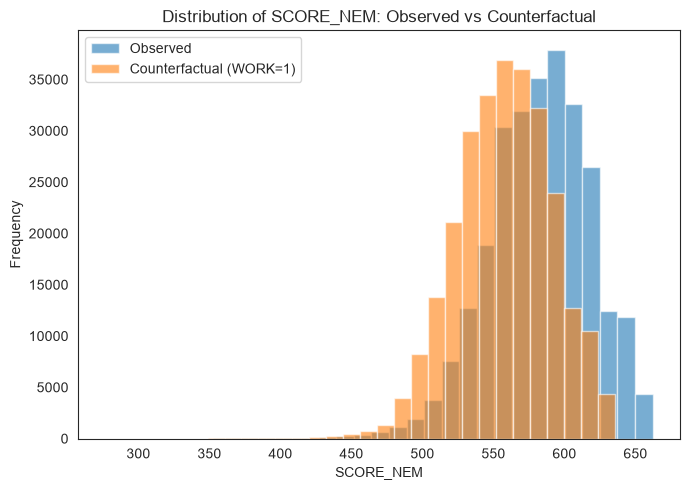

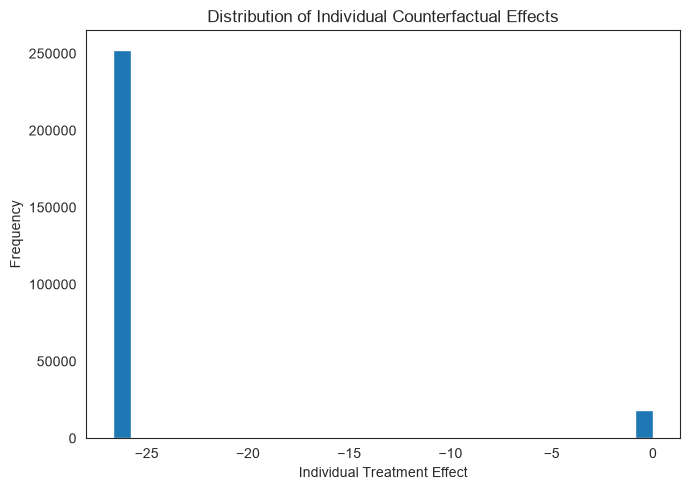


All figures generated successfully.


In [66]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

Y_VAR = "SCORE_NEM"

X_VARS = [
    "SCHOOL_TYPE",
    "GRADUATION_YEAR",
    "GENDER",
    "MOTHER_EDUCATION",
    "INCOME_PERCENTILE",
    "HOW_MANY_WORK",
    "WORK",
    "RURAL",
]

df_model = df[X_VARS]
df_model[Y_VAR]=df[Y_VAR]

X = sm.add_constant(df_model[X_VARS])
y = df_model[Y_VAR]

model = sm.OLS(y, X).fit()

print("\nOLS model fitted successfully.")
print(model.summary())

df_model["SCORE_NEM_observed"] = model.predict(X)
X_cf = X.copy()
X_cf.loc[X_cf["WORK"] == 0, "WORK"] = 1
df_model["SCORE_NEM_counterfactual"] = model.predict(X_cf)

df_model["Individual_Effect"] = (
    df_model["SCORE_NEM_counterfactual"] - df_model["SCORE_NEM_observed"]
)

df_model[
    ["WORK", "SCORE_NEM_observed", "SCORE_NEM_counterfactual", "Individual_Effect"]
].to_csv(
    "counterfactual_WORK_0_to_1.csv",
    sep=";",
    index=False
)

print("\nCounterfactual results saved to 'counterfactual_WORK_0_to_1.csv'.")


avg_observed = df_model["SCORE_NEM_observed"].mean()
avg_counterfactual = df_model["SCORE_NEM_counterfactual"].mean()
avg_effect = df_model["Individual_Effect"].mean()

print("\nAverage Effects:")
print(f"Observed mean SCORE_NEM: {avg_observed:.3f}")
print(f"Counterfactual mean SCORE_NEM (WORK=1): {avg_counterfactual:.3f}")
print(f"Average Treatment Effect (ATE): {avg_effect:.3f}")


plt.figure(figsize=(6, 5))
plt.bar(
    ["Observed", "Counterfactual (WORK=1)"],
    [avg_observed, avg_counterfactual],
    edgecolor="black"
)
plt.ylabel("Estimated SCORE_NEM")
plt.title("Counterfactual Effect of WORK=1")
plt.tight_layout()
plt.savefig("Figure_WORK_Observed_vs_Counterfactual.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(
    df_model["SCORE_NEM_observed"],
    bins=30,
    alpha=0.6,
    label="Observed"
)
plt.hist(
    df_model["SCORE_NEM_counterfactual"],
    bins=30,
    alpha=0.6,
    label="Counterfactual (WORK=1)"
)
plt.xlabel("SCORE_NEM")
plt.ylabel("Frequency")
plt.title("Distribution of SCORE_NEM: Observed vs Counterfactual")
plt.legend()
plt.tight_layout()
plt.savefig("Figure_WORK_Distribution_Comparison.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(df_model["Individual_Effect"], bins=30)
plt.xlabel("Individual Treatment Effect")
plt.ylabel("Frequency")
plt.title("Distribution of Individual Counterfactual Effects")
plt.tight_layout()
plt.savefig("Figure_WORK_Individual_Effects.png", dpi=300)
plt.show()

print("\nAll figures generated successfully.")
